# Practice 7.
Objectives:

1. Understand the Random Forests.
2. See the effects of changing the parameters of the tree.
3. AQplication:
Data base: Datasets for "The Elements of Statistical Learning" (https://web.stanford.edu/~hastie/ElemStatLearn/data.html)

Database: coronary heart disease (CHD), https://web.stanford.edu/~hastie/ElemStatLearn/datasets/SAheart.data

Predict CHD (1 or 0)
4. Reference: L. Breiman, “Random Forests”, Machine Learning, 45(1), 5-32, 2001.

In [1]:
import pandas as pd
import os 
import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import  RandomForestRegressor
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

## Let us load the database and   clean it up.

In [2]:
File = "SouthAfricanHeartDesease.csv"
Filename = os.path.join(os.getcwd(),'Data',File)
print(f'Filename with path: \n {Filename}')
Data = pd.read_csv(Filename)
Data.head().T

Filename with path: 
 c:\mlearn-lab\SeventhPractice\Data\SouthAfricanHeartDesease.csv


,0,1,2,3,4
row.names,1,2,3,4,5
sbp,160,144,118,170,134
tobacco,12.0,0.01,0.08,7.5,13.6
ldl,5.73,4.41,3.48,6.41,3.5
adiposity,23.11,28.61,32.28,38.03,27.78
famhist,Present,Absent,Present,Present,Present
typea,49,55,52,51,60
obesity,25.3,28.87,29.14,31.99,25.99
alcohol,97.2,2.06,3.81,24.26,57.34
age,52,63,46,58,49


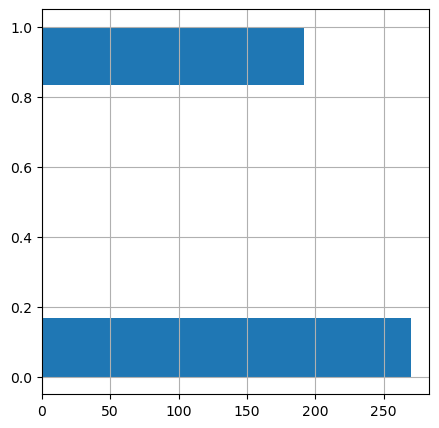

In [3]:
Coding_famhist ={'Present':1,'Absent':0}
Data['famhist'] = Data['famhist'].map(Coding_famhist)
ax =Data['famhist'].hist(figsize= (5,5),orientation="horizontal",bins = 6)

Data.drop(columns = ['row.names'],inplace = True)

##  First we partition database into train and test
### Note the helper function

In [4]:
def PartitionOfDatabase(Data,Fraction = 0.75):
    NumSamples, NumFeatures = Data.shape
    Index = list(range(NumSamples))
    RandomIndex = np.random.permutation(Index)
    NumTrainElements = int(Fraction*NumSamples)
    TrainIndex = RandomIndex[:NumTrainElements]
    TestIndex = RandomIndex[NumTrainElements:]
    TrainDB = Data.iloc[TrainIndex]
    TestDB = Data.iloc[TestIndex]
    return TrainDB,TestDB


In [5]:
TrainDB,TestDB = PartitionOfDatabase(Data,Fraction = 0.75)
y = TrainDB['chd']
InputFeatures = [fea for fea in TrainDB.columns if  fea != 'chd']
print(f' Input variables: \n {InputFeatures}')
print('_'*50)
X = TrainDB[InputFeatures]

 Input variables: 
 ['sbp', 'tobacco', 'ldl', 'adiposity', 'famhist', 'typea', 'obesity', 'alcohol', 'age']
__________________________________________________


##  Now we create the object Random Forest and fit it

In [6]:
clf = RandomForestClassifier(n_estimators=100, max_features='sqrt', oob_score=True,n_jobs=4, min_samples_split=2, min_samples_leaf=1, random_state=0)
clf.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,True


###  We compute the error on the test database  and compare it with the out of bag estimate

In [7]:
# 1. Prepare the test data using the same features as the training set
X_test = TestDB[InputFeatures]
y_test = TestDB['chd']

# 2. Compute the accuracy on the test set 
test_accuracy = clf.score(X_test, y_test)
test_error = 1 - test_accuracy

# 3. Compute the OOB error rate (1 - oob_score_)
oob_error = 1 - clf.oob_score_

# 4. Print the performance results
print(f'Out of Bag estimate of the error: {oob_error*100:2.2f} %')
print(f'Test database error rate:        {test_error*100:2.2f} %')


Out of Bag estimate of the error: 29.48 %
Test database error rate:        31.03 %


 ###  <font color='red'> Excercise: </font>
 1. Run several times: TrainDB,TestDB = PartitionOfDatabase(Data,Fraction = 0.75), and compare the Out of Bag Estimate and the test database error rate.
 2. Explain in one sentence why the out of bag is usefull.

## Let us see the importance of the variables

In [8]:
importances = clf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': InputFeatures,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print('\n' + '='*40)
print(f'{"RANKED FEATURE IMPORTANCES":^40}')
print('='*40)
print(feature_importance_df.to_string(index=False, formatters={'Importance': '{:.4f}'.format}))
print('='*40)


       RANKED FEATURE IMPORTANCES       
  Feature Importance
  tobacco     0.1635
      age     0.1594
      ldl     0.1193
adiposity     0.1107
      sbp     0.1096
    typea     0.1066
  obesity     0.1031
  alcohol     0.0843
  famhist     0.0435


### We will use pandas to create a visualization

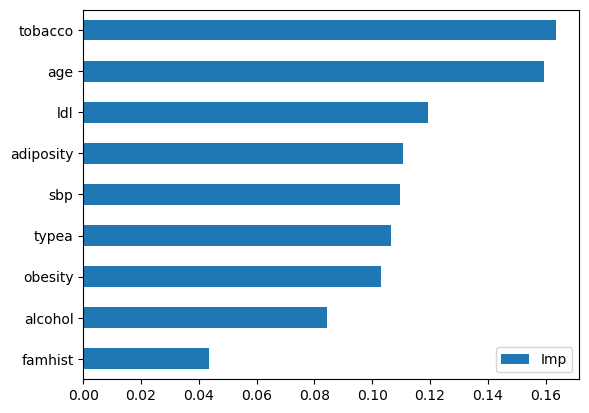

In [9]:
FeaImp=pd.DataFrame(data =clf.feature_importances_,index =  InputFeatures,columns = ['Imp'])
FeaImp.sort_values(by = ['Imp'],inplace = True)
ax = FeaImp.plot.barh()

## Remember the tree we created in the last practice

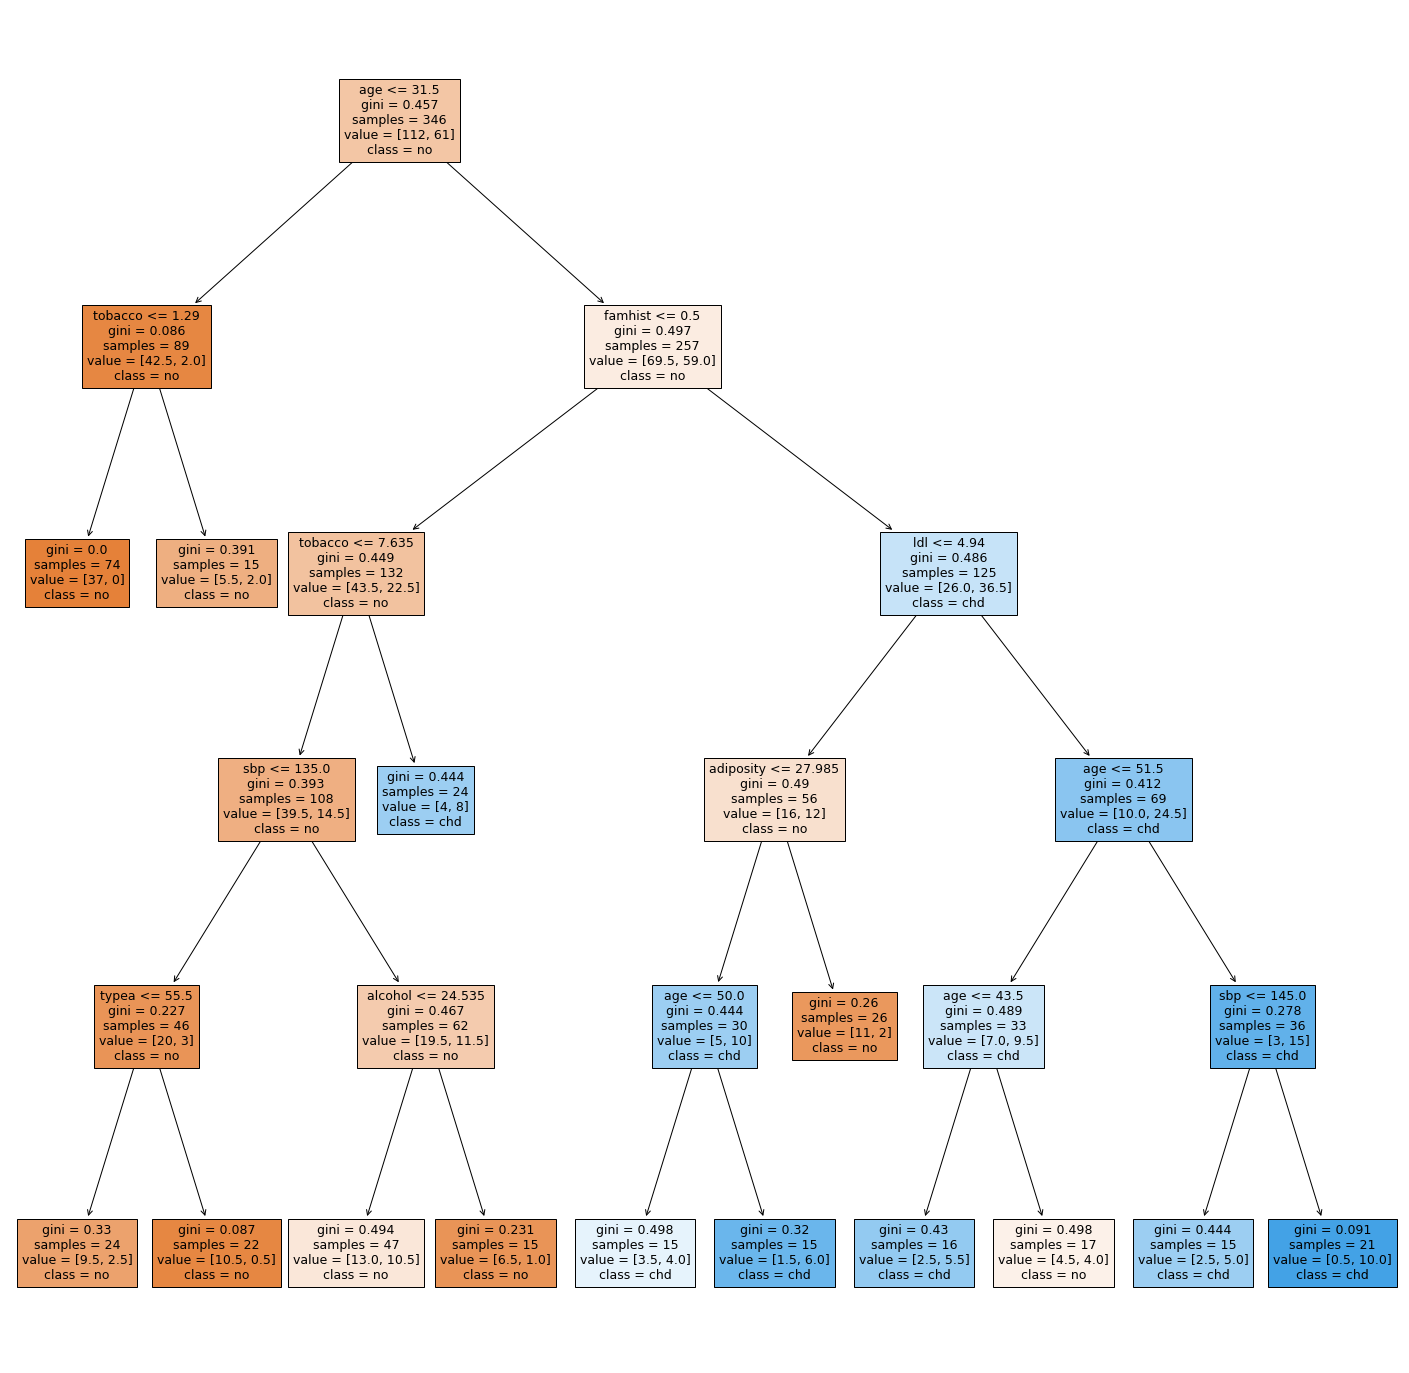

###  <font color='red'> Excercise: </font>
 1. Compare the ranking of the decision tree with the ranking given by the random forest. Provide a one parragraph explanation of the similarities. Note that family history is high in the hierarchy of decision trees but low in the one of random forests. In the explanation reflect about the fact that random forests is simulating a universe of different databases.

##  Performance on train
**Definition:**
$\texttt{accuracy}(y, \hat{y}) = \frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples}-1} 1(\hat{y}_i = y_i)$


Accuracy (train)  100.0% 
[[223   0]
 [  0 123]]


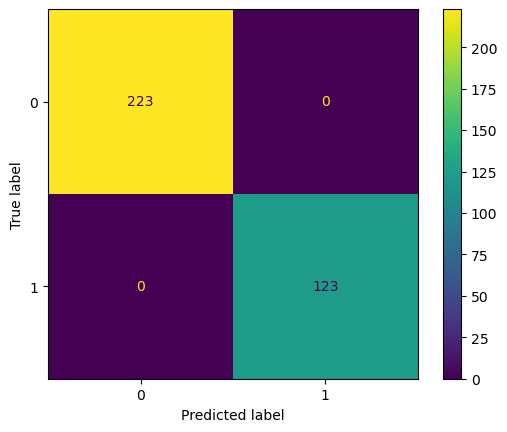

In [10]:
y_hat = clf.predict(X)
accuracy = accuracy_score(y, y_hat)
print("Accuracy (train)  %0.1f%% " % ( accuracy * 100))
print(confusion_matrix(y, y_hat))
ConfusionMatrixDisplay.from_predictions(y, y_hat)
plt.show()

## Remember for a single tree we had 
Accuracy (train)  78.6% 

[[195  29]

 [ 45  77]]

## Performance on test
### Note it is almost the same that the Out of Bag estimate.

Accuracy (test)  69.0% 
[[68 11]
 [25 12]]


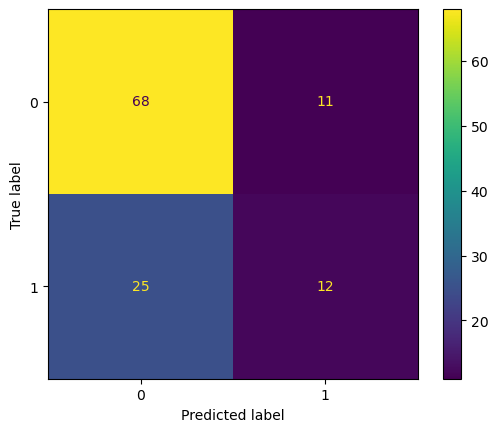

In [11]:
y_tst = TestDB['chd']
X_tst = TestDB[InputFeatures]
y_hat_tst = clf.predict(X_tst)
accuracy = accuracy_score(y_tst, y_hat_tst)
print("Accuracy (test)  %0.1f%% " % ( accuracy * 100))
print(confusion_matrix(y_tst, y_hat_tst))
ConfusionMatrixDisplay.from_predictions(y_tst, y_hat_tst)
plt.show()

## Better than the case of one only tree
Accuracy (test)  63.8% 

[[58 20]
 
 [22 16]]


### Homework: <font color='red'>   Plot the evolution of the Out of Bag error and the test error as a function of the number of trees.  For instance from 100 to 2000 in increments of 100.</font> 

### Homework: <font color='red'>    **Important**: we still have too many false negatives. Try  changing the class_weight = {0:0.5,1:0.5}.  </font>



###  Next we will look for the best combination of parameters of the random forest classifiers by cross validation.
### **Important**: Check the memory consumption of the process.

In [12]:
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.ensemble import RandomForestClassifier

# Define parameter grid for RandomForestClassifier
param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_depth': [10, 20, None]
}

# Set up KFold cross-validation
kfold = KFold(n_splits=5, shuffle=True, random_state=0)

# Create GridSearchCV
grid_search = GridSearchCV(
    RandomForestClassifier(oob_score=True, n_jobs=4, random_state=0),
    param_grid,
    cv=kfold,
    scoring='accuracy',
    n_jobs=4,
    verbose=1
)

# Fit the grid search
grid_search.fit(X, y)

# Get the best model
best_clf = grid_search.best_estimator_

print(f'Best parameters: {grid_search.best_params_}')
print(f'Best CV score: {grid_search.best_score_*100:.2f} %')
print('_'*50)

# Evaluate on test set
X_test = TestDB[InputFeatures]
y_test = TestDB['chd']

test_accuracy = best_clf.score(X_test, y_test)
test_error = 1 - test_accuracy

oob_error = 1 - best_clf.oob_score_

print(f'Out of Bag estimate of the error: {oob_error*100:2.2f} %')
print(f'Test database error rate:        {test_error*100:2.2f} %')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best parameters: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 200}
Best CV score: 72.53 %
__________________________________________________
Out of Bag estimate of the error: 27.46 %
Test database error rate:        29.31 %


 ### Excercise: <font color='red'> Create an infographic for the work done </font>
 Use either notebooklm or any chat.
 Refine the prompt so that the explanation of the work done is clear.

### Excercise: <font color='red'> Create an executive report </font>
Write a short assessment of the work done. Difficulties, challenges, and proposals for a solution.
